In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy 
import cmocean 
import cartopy.crs as ccrs 

In [2]:
foccus = '/lustre/storeB/project/fou/hi/foccus'
filepath = 'malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/2024-04-02_.ckpt_e010_s020000.nc' #inference results from my own run

#inference results 

In [3]:
ds = xr.open_dataset(f'{foccus}/{filepath}')

In [4]:
ds

<xarray.Dataset> Size: 5GB
Dimensions:            (X: 1148, Y: 2747, time: 17)
Coordinates:
  * X                  (X) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * Y                  (Y) float64 22kB 0.0 800.0 ... 2.196e+06 2.197e+06
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 13MB ...
    longitude          (X, Y) float32 13MB ...
    h                  (time, X, Y) float32 214MB ...
    salinity_0         (time, X, Y) float32 214MB ...
    sea_mask           (time, X, Y) float32 214MB ...
    temperature_0      (time, X, Y) float32 214MB ...
    ...                 ...
    rain               (time, X, Y) float32 214MB ...
    river_binary_mask  (time, X, Y) float32 214MB ...
    sin_julian_day     (time, X, Y) float32 214MB ...
    sin_latitude       (time, X, Y) float32 214MB ...
    sin_local_time     (time, X, Y) float32 214MB ...
    sin_longitude      (time, X, Y) float32 214MB ...

In [5]:
#okay so plotting f / h seems simple enough, because we already have them both - but do we need to interpolate?? maybe not ..

f = ds.f
h = ds.h 

In [6]:
#then cut out an area - it is of interst to study either Vestlandet or Lofoten as discussed with Matheusz
#We expect the bottom topography to impact the surface currents. We should see that f/h follows the ocean currents u and v

import pyresample
#select an area
lon_min, lon_max = 11.83083, 15.59072
lat_min, lat_max = 67.41791, 69.20699


lon_ulc, lon_llc = 11.83, 11.83
lon_lrc, lon_urc = 15.59, 15.59
lat_urc, lat_ulc = 69.21, 69.21
lat_llc, lat_lrc = 67.41, 67.41

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid = pyresample.geometry.GridDefinition(lons=ds.longitude.values, lats = ds.latitude.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

Lofoten = ds.isel(Y=slice(y_min, y_max+1), X = slice(x_min, x_max +1))

X min: 572, X max: 862
Y min: 1680, Y max: 1986


In [7]:
Lofoten

<xarray.Dataset> Size: 147MB
Dimensions:            (X: 291, Y: 307, time: 17)
Coordinates:
  * X                  (X) float64 2kB 4.576e+05 4.584e+05 ... 6.896e+05
  * Y                  (Y) float64 2kB 1.344e+06 1.345e+06 ... 1.589e+06
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 357kB 66.75 66.76 66.77 ... 69.83 69.83
    longitude          (X, Y) float32 357kB 14.4 14.42 14.43 ... 12.96 12.97
    h                  (time, X, Y) float32 6MB ...
    salinity_0         (time, X, Y) float32 6MB ...
    sea_mask           (time, X, Y) float32 6MB ...
    temperature_0      (time, X, Y) float32 6MB ...
    ...                 ...
    rain               (time, X, Y) float32 6MB ...
    river_binary_mask  (time, X, Y) float32 6MB ...
    sin_julian_day     (time, X, Y) float32 6MB ...
    sin_latitude       (time, X, Y) float32 6MB ...
    sin_local_time     (time, X, Y) float32 6MB ...
    sin_longitude      (time, X, Y) float32 6MB ...

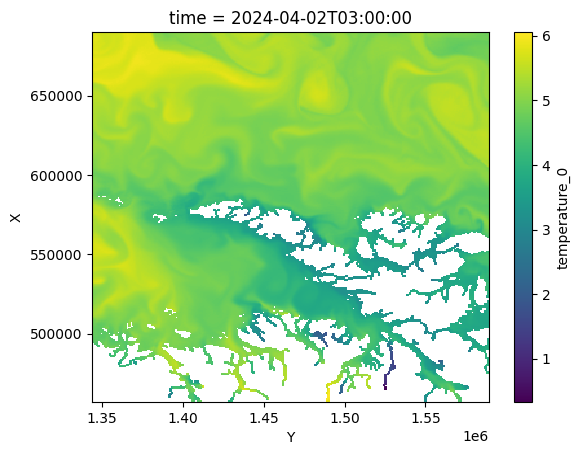

In [8]:
#just a quick check that it works
Lofoten.temperature_0.isel(time = 1).plot()

In [9]:
h_L = Lofoten.h 
f_L = Lofoten.f
zeta = Lofoten.zeta


In [10]:
print(h_L.shape)
print(zeta.shape)

(17, 291, 307)
(17, 291, 307)


In [21]:
f_h = f_L.values/h_L.values
f_h[0,slice(x_min,x_max),slice(y_min, y_max)]
np.printoptions(np.inf)
print(f_h)


[[[1.34002939e-05 1.34009051e-05 1.34015163e-05 ... 1.35760756e-05
   1.35766195e-05 1.35771643e-05]
  [1.34007114e-05 1.34013226e-05 1.34019338e-05 ... 1.35764985e-05
   1.35770433e-05 1.35775872e-05]
  [1.34011307e-05 1.34017419e-05 1.34023530e-05 ... 1.35769224e-05
   1.35774662e-05 1.35780110e-05]
  ...
  [1.39596850e-07 1.38451668e-07 1.37171170e-07 ... 4.86375349e-08
   4.86765153e-08 4.87209455e-08]
  [1.35197908e-07 1.33986475e-07 1.32607354e-07 ... 4.86511027e-08
   4.86866512e-08 4.87276957e-08]
  [1.31198746e-07 1.29997176e-07 1.28599993e-07 ... 4.86762630e-08
   4.87084257e-08 4.87458962e-08]]

 [[           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  ...
  [           nan            nan            nan ...            nan
          

In [29]:
step = 5
min_l = -0.5e-5 
max_l = 1.44e-5
custom = np.linspace(min_l, max_l, 20)

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


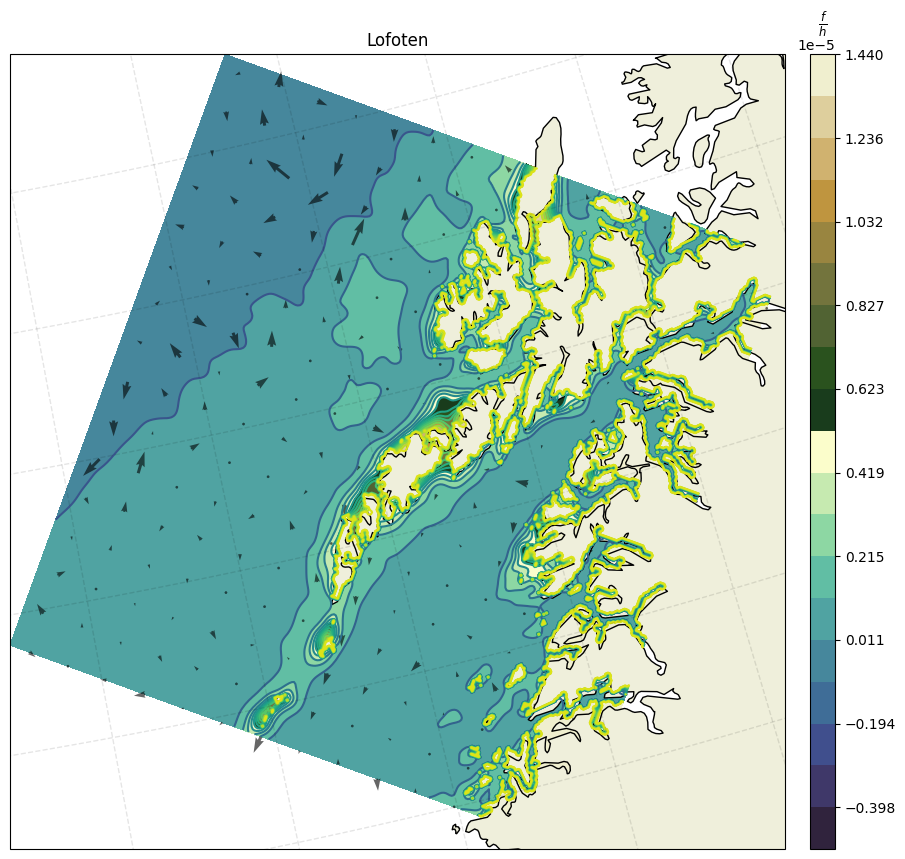

In [24]:
fig,ax = plt.subplots(figsize = (10,12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
im = ax.contour(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
im2 = ax.contourf(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
ax.quiver(Lofoten.longitude.values[::step, ::step], Lofoten.latitude.values[::step, ::step], Lofoten.u_eastward_0[1,:,:].values[::step, ::step], Lofoten.v_northward_0[1,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
cbar = fig.colorbar(im2, ax=ax, cax = cax, extend = "both")
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
gl.xlabels_top = False
ax.set_title('Lofoten')
cbar.ax.set_title(r'$\frac{f}{h}$')
ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')

In [31]:
#Now do an average of the ocean velocities to find the avg flow and compare to f/h 
#Maybe just use xarray ?? :) or too easy of an fix 
mean_u_vel = Lofoten['u_eastward_0'].resample(time = 'D').mean(dim = 'time')
mean_v_vel = Lofoten['v_northward_0'].resample(time = 'D').mean(dim = 'time')

In [32]:
mean_v_vel

<xarray.DataArray 'v_northward_0' (time: 3, X: 291, Y: 307)> Size: 1MB
array([[[-1.3644674e-03, -2.7205232e-03, -2.2620484e-03, ...,
         -6.1427607e-05, -8.5541164e-04, -9.4639091e-04],
        [-1.1884118e-03, -5.0005381e-04, -1.2858106e-03, ...,
         -1.4469611e-04, -1.1319281e-03, -1.5616999e-04],
        [-3.6277334e-04, -4.9098732e-04, -1.1236269e-03, ...,
          2.2962486e-04, -8.1416476e-04,  1.6653705e-04],
        ...,
        [-1.6934130e-01, -1.8089738e-01, -2.1113215e-01, ...,
         -2.5203842e-01, -2.4757648e-01, -2.2225140e-01],
        [-1.5472022e-01, -1.5343682e-01, -1.8049282e-01, ...,
         -2.8541958e-01, -2.8653765e-01, -2.9039848e-01],
        [-1.1915988e-01, -1.6291660e-01, -1.9505006e-01, ...,
         -3.6555609e-01, -3.5047513e-01, -3.1297901e-01]],

       [[-6.7119529e-03, -1.0363002e-02, -9.2034414e-03, ...,
          1.2962885e-03, -2.0003628e-03, -3.2806396e-03],
        [-5.5712159e-03, -3.1111510e-03, -7.3508359e-03, ...,
          1.2270762e-03, -2.3203399e-03,  1.9845566e-04],
        [-2.7209951e-03, -3.6470655e-03, -4.8611942e-03, ...,
         -3.7330639e-04, -2.5961923e-03,  2.1346551e-03],
...
         -1.5241550e-01, -1.7701493e-01, -1.4692028e-01],
        [-7.0945486e-02, -1.1227616e-02, -1.9323330e-02, ...,
         -1.4821610e-01, -1.3751876e-01, -1.3212378e-01],
        [-2.1066938e-02, -2.0414617e-02, -6.9310114e-02, ...,
         -1.9640107e-01, -1.7656474e-01, -1.3138707e-01]],

       [[-9.1153393e-03, -1.4193059e-02, -1.2638369e-02, ...,
          2.9036992e-03, -1.9934271e-03, -4.1937525e-03],
        [-7.9121329e-03, -4.8103160e-03, -1.0698216e-02, ...,
          3.0701256e-03, -2.3940899e-03,  9.6278079e-04],
        [-3.5310746e-03, -5.8748396e-03, -6.6454886e-03, ...,
         -6.7620166e-04, -2.7808810e-03,  3.8546280e-03],
        ...,
        [-8.5396633e-02,  4.4227097e-02,  1.1196644e-02, ...,
          5.4933984e-02,  5.1575720e-02,  6.9760576e-02],
        [-3.2005954e-01, -2.3162970e-01, -1.8067698e-01, ...,
          1.5250391e-01,  1.7801058e-01,  1.8884569e-01],
        [-3.8646442e-01, -3.7432727e-01, -3.9738205e-01, ...,
          1.6400959e-01,  1.7243671e-01,  1.9962926e-01]]],
      shape=(3, 291, 307), dtype=float32)
Coordinates:
  * X        (X) float64 2kB 4.576e+05 4.584e+05 ... 6.888e+05 6.896e+05
  * Y        (Y) float64 2kB 1.344e+06 1.345e+06 ... 1.588e+06 1.589e+06
  * time     (time) datetime64[ns] 24B 2024-04-02 2024-04-03 2024-04-04

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


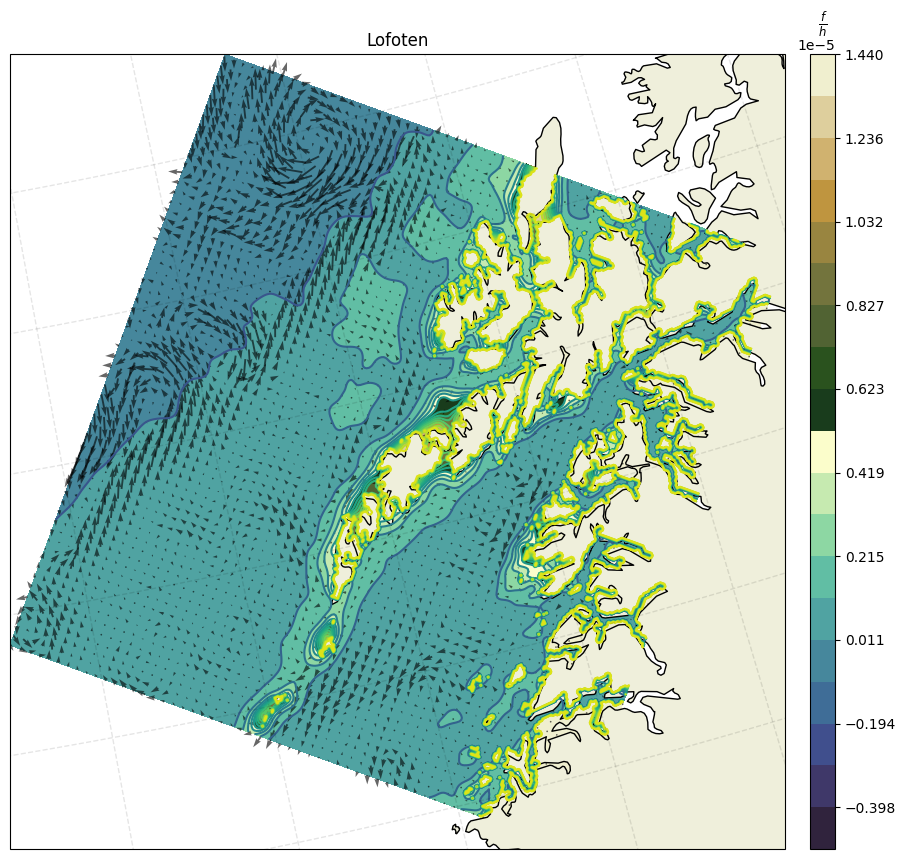

In [33]:
fig,ax = plt.subplots(figsize = (10,12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
im = ax.contour(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
im2 = ax.contourf(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
ax.quiver(Lofoten.longitude.values[::step, ::step], Lofoten.latitude.values[::step, ::step], mean_u_vel[0,:,:].values[::step, ::step], mean_v_vel[0,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
cbar = fig.colorbar(im2, ax=ax, cax = cax, extend = "both")
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
gl.xlabels_top = False
ax.set_title('Lofoten')
cbar.ax.set_title(r'$\frac{f}{h}$')
ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')

In [34]:
from dataloader import open_dataset

In [36]:
ds_lof = open_dataset(file = f'{foccus}/{filepath}', region= 'lofoten')

In [37]:
ds_lof

In [ ]:
ds_sula = open_dataset(file = f'{foccus}/{filepath}', region= 'sulafjorden')
ds_oslo = open_dataset(file = f'{foccus}/{filepath}', region= 'oslofjorden')
#og et lengre uti for å se dynamikken et område med kun hav, feks ute ved kontinentalen
